In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Business Problem

In [5]:


# Load dataset
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

# Display basic information
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 2. Data Understanding

In [6]:
# Basic Data understanding

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nTarget Distribution:")
print(df['Class'].value_counts())

print("\nFraud Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Shape: (284807, 31)

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
0

Target Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


# 3. EDA

In [7]:
import matplotlib.pyplot as plt

# Transaction amount distribution
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

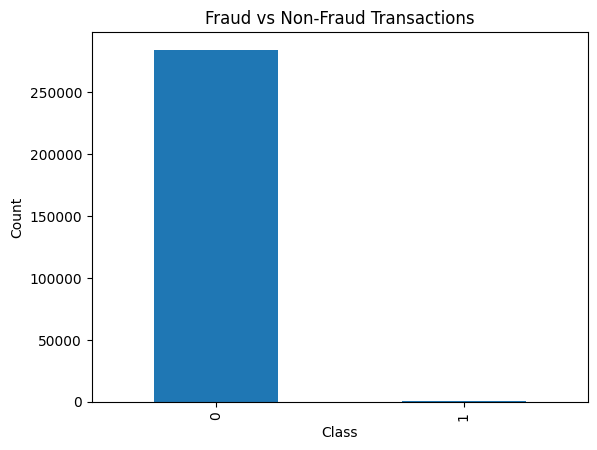

In [8]:
# Fraud vs Non-Fraud count

df['Class'].value_counts().plot(kind='bar')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [9]:
# Fraud transaction amount analysis

fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]

print("Fraud Amount Stats:")
print(fraud['Amount'].describe())

print("\nNon Fraud Amount Stats:")
print(non_fraud['Amount'].describe())

Fraud Amount Stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Non Fraud Amount Stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


# 4. Preprocessing

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nTrain Fraud Ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest Fraud Ratio:")
print(y_test.value_counts(normalize=True))

Train Shape: (227845, 30)
Test Shape: (56962, 30)

Train Fraud Ratio:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Test Fraud Ratio:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Amount', 'Time']] = scaler.fit_transform(
    X_train[['Amount', 'Time']]
)

X_test[['Amount', 'Time']] = scaler.transform(
    X_test[['Amount', 'Time']]
)

# 5. Baseline Model

In [15]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [17]:
y_pred = baseline_model.predict(X_test)

y_prob = baseline_model.predict_proba(X_test)[:, 1]

In [18]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nPrecision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9558983554029378

Precision: 0.8289473684210527
Recall: 0.6428571428571429
F1 Score: 0.7241379310344828

Confusion Matrix:
[[56851    13]
 [   35    63]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



# 6. Imbalance Handling

In [19]:
from imblearn.over_sampling import SMOTE

In [20]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


# 7. XGBoost

In [22]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [24]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nPrecision:", precision_score(y_test, y_pred_xgb))

print("Recall:", recall_score(y_test, y_pred_xgb))

print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

ROC-AUC: 0.9772934778863712

Precision: 0.3739130434782609
Recall: 0.8775510204081632
F1 Score: 0.524390243902439

Confusion Matrix:
[[56720   144]
 [   12    86]]


# 8. Threshold Optimization

In [25]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

for thresh in thresholds:

    y_thresh = (y_prob_xgb >= thresh).astype(int)

    precision = precision_score(y_test, y_thresh)
    recall = recall_score(y_test, y_thresh)
    f1 = f1_score(y_test, y_thresh)

    print(f"Threshold: {thresh}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1: {f1:.3f}")
    print("-"*40)

Threshold: 0.1
Precision: 0.064
Recall: 0.918
F1: 0.119
----------------------------------------
Threshold: 0.2
Precision: 0.114
Recall: 0.888
F1: 0.202
----------------------------------------
Threshold: 0.3
Precision: 0.183
Recall: 0.888
F1: 0.303
----------------------------------------
Threshold: 0.4
Precision: 0.267
Recall: 0.878
F1: 0.410
----------------------------------------
Threshold: 0.5
Precision: 0.374
Recall: 0.878
F1: 0.524
----------------------------------------
Threshold: 0.6
Precision: 0.483
Recall: 0.878
F1: 0.623
----------------------------------------
Threshold: 0.7
Precision: 0.531
Recall: 0.867
F1: 0.659
----------------------------------------
Threshold: 0.8
Precision: 0.596
Recall: 0.857
F1: 0.703
----------------------------------------
Threshold: 0.9
Precision: 0.719
Recall: 0.837
F1: 0.774
----------------------------------------


# 9. Explainability

In [26]:
import shap

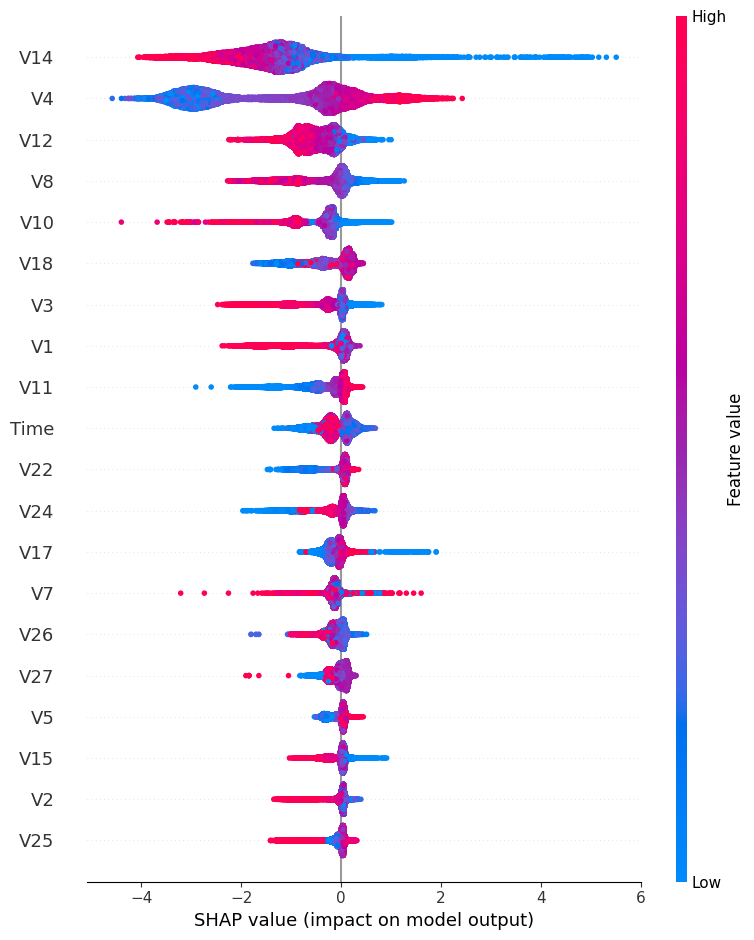

In [27]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

# 10. Business Conclusions

In [29]:
# Logistic Regression train probabilities
y_train_prob_lr = baseline_model.predict_proba(X_train)[:,1]

# XGBoost train probabilities
y_train_prob_xgb = xgb_model.predict_proba(X_train)[:,1]

In [32]:
from sklearn.metrics import roc_auc_score

train_auc_lr = roc_auc_score(y_train, y_train_prob_lr)
train_auc_xgb = roc_auc_score(y_train, y_train_prob_xgb)
test_auc_lr = roc_auc_score(y_test, y_prob)
test_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("LR Test AUC:", test_auc_lr)

print("XGB Test AUC:", test_auc_xgb)
print("LR Train AUC:", train_auc_lr)
print("XGB Train AUC:", train_auc_xgb)

LR Test AUC: 0.9558983554029378
XGB Test AUC: 0.9772934778863712
LR Train AUC: 0.9820984145924261
XGB Train AUC: 0.9999699940950075


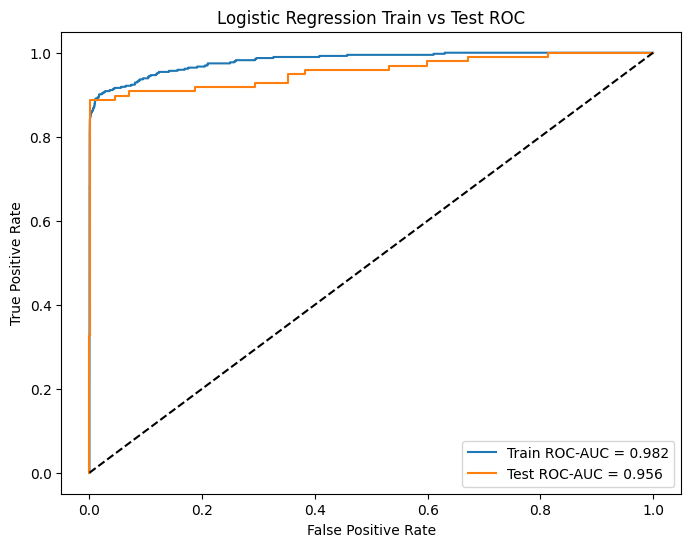

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression Train ROC
fpr_train_lr, tpr_train_lr, _ = roc_curve(y_train, y_train_prob_lr)
# Logistic Regression Test ROC
fpr_test_lr, tpr_test_lr, _ = roc_curve(y_test, y_prob)
# Plot
plt.figure(figsize=(8,6))
plt.plot(
    fpr_train_lr,
    tpr_train_lr,
    label=f"Train ROC-AUC = {train_auc_lr:.3f}"
)
plt.plot(
    fpr_test_lr,
    tpr_test_lr,
    label=f"Test ROC-AUC = {test_auc_lr:.3f}"
)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression Train vs Test ROC")
plt.legend()
plt.show()

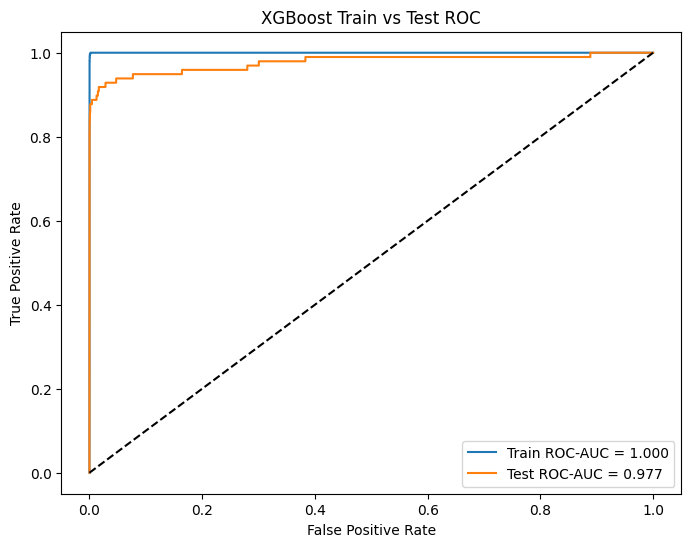

In [34]:
# XGBoost Train ROC
fpr_train_xgb, tpr_train_xgb, _ = roc_curve(
    y_train,
    y_train_prob_xgb
)
# XGBoost Test ROC
fpr_test_xgb, tpr_test_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)
# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr_train_xgb,
    tpr_train_xgb,
    label=f"Train ROC-AUC = {train_auc_xgb:.3f}"
)
plt.plot(
    fpr_test_xgb,
    tpr_test_xgb,
    label=f"Test ROC-AUC = {test_auc_xgb:.3f}"
)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost Train vs Test ROC")
plt.legend()
plt.show()

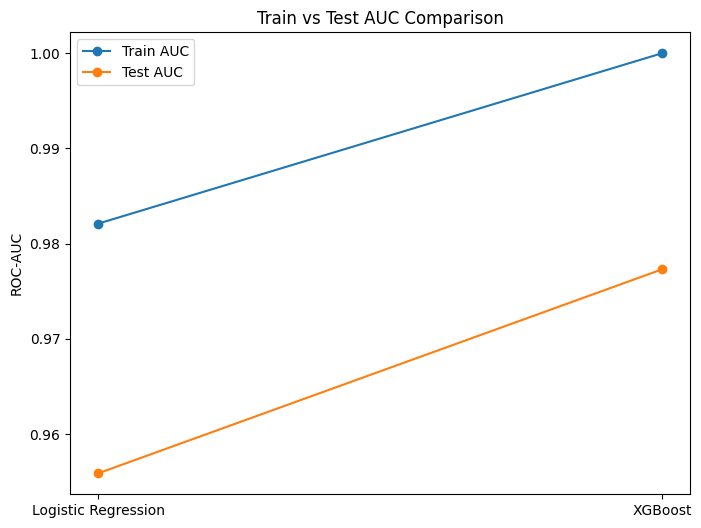

In [35]:
models = ['Logistic Regression', 'XGBoost']
train_auc = [train_auc_lr, train_auc_xgb]
test_auc = [test_auc_lr, test_auc_xgb]
x = range(len(models))
plt.figure(figsize=(8,6))
plt.plot(x, train_auc, marker='o', label='Train AUC')
plt.plot(x, test_auc, marker='o', label='Test AUC')
plt.xticks(x, models)
plt.ylabel("ROC-AUC")
plt.title("Train vs Test AUC Comparison")
plt.legend()
plt.show()

In [37]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'ROC-AUC': [0.956, 0.977],
    'Precision': [0.829, 0.374],
    'Recall': [0.643, 0.878],
    'F1 Score': [0.724, 0.524]
})

comparison

,Model,ROC-AUC,Precision,Recall,F1 Score
0,Logistic Regression,0.956,0.829,0.643,0.724
1,XGBoost,0.977,0.374,0.878,0.524


In [38]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.428683
12,V12,0.118369
10,V10,0.071744
4,V4,0.046827
8,V8,0.029100
3,V3,0.022884
13,V13,0.022775
18,V18,0.017893
26,V26,0.015844
17,V17,0.015774


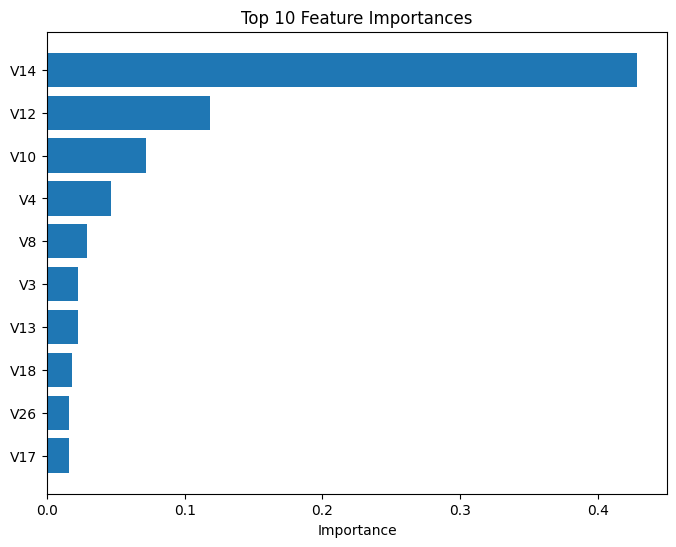

In [39]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 10 Feature Importances")

plt.show()

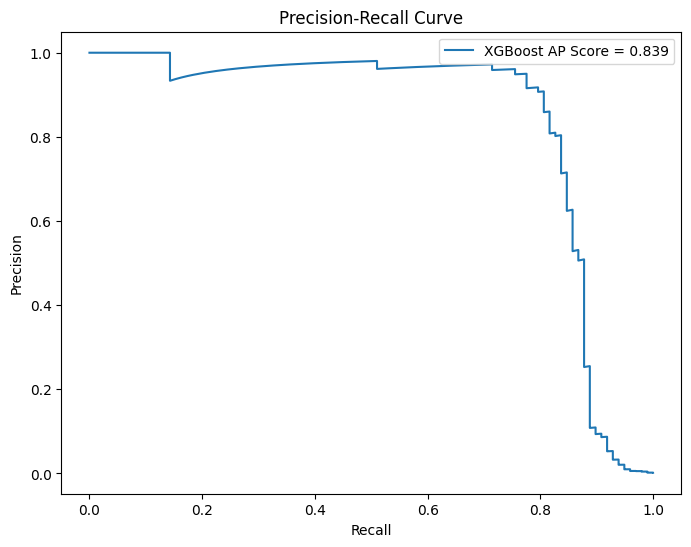

In [40]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb
)
# Average Precision Score
ap_score = average_precision_score(
    y_test,
    y_prob_xgb
)
# Plot
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f'XGBoost AP Score = {ap_score:.3f}'
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()